<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/pipeline_biodiversidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>>> ETAPA 1 COMPLETA: Datos de Biodiversidad cargados en el motor SQL.

>>> ETAPA 2 COMPLETA: Consulta de Alerta Crítica ejecutada con éxito.
           Especie  Total_Ejemplares  Area_Promedio_KM2
0    Condor Andino                20               37.5
1           Jaguar                 1                8.2
2  Oso de Anteojos                 8               13.8

>>> ETAPA 3 COMPLETA: Generando Dashboard de Control...


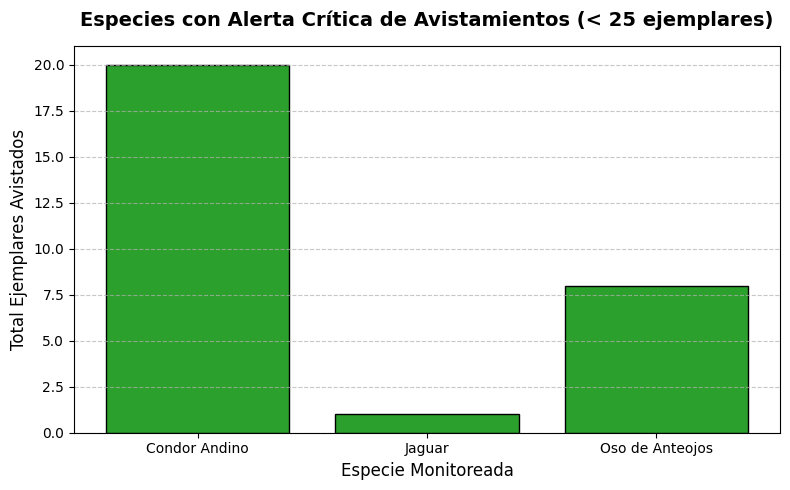

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# ETAPA 1: EXTRACCIÓN Y CARGA (ETL) - Simulación de Base de Datos Origen
# ==============================================================================
conexion = sqlite3.connect(":memory:")

# Tabla de Hechos: Monitoreo de Campo
df_avistamientos = pd.DataFrame({
    "id_avistamiento": [1, 2, 3, 4, 5, 6, 7],
    "id_especie": [101, 102, 103, 101, 104, 102, 105],
    "conteo_ejemplares": [5, 12, 1, 3, 45, 8, 2],
    "area_km2": [12.5, 45.0, 8.2, 15.1, 120.0, 30.0, 5.4]
})

# Tabla de Dimensión: Catálogo de Especies
df_especies = pd.DataFrame({
    "id_especie": [101, 102, 103, 104, 105],
    "nombre_comun": ["Oso de Anteojos", "Condor Andino", "Jaguar", "Danta", "Titi Cabeciblanco"],
    "categoria_amenaza": ["Vulnerable", "Critico", "Casi Amenazado", "Preocupacion Menor", "Critico"]
})

df_avistamientos.to_sql("avistamientos", conexion, index=False, if_exists="replace")
df_especies.to_sql("especies", conexion, index=False, if_exists="replace")

print(">>> ETAPA 1 COMPLETA: Datos de Biodiversidad cargados en el motor SQL.")

# ==============================================================================
# ETAPA 2: PROCESAMIENTO Y REGLAS DE NEGOCIO (SQL)
# ==============================================================================
consulta_pipeline = """
SELECT
    especies.nombre_comun AS Especie,
    SUM(avistamientos.conteo_ejemplares) AS Total_Ejemplares,
    AVG(avistamientos.area_km2) AS Area_Promedio_KM2
FROM
    avistamientos
INNER JOIN
    especies ON avistamientos.id_especie = especies.id_especie
WHERE
    avistamientos.area_km2 > 6.0
GROUP BY
    especies.nombre_comun
HAVING
    SUM(avistamientos.conteo_ejemplares) < 25
"""

# Almacenar el resultado procesado listo para el reporte
df_reporte_bi = pd.read_sql(consulta_pipeline, conexion)
print("\n>>> ETAPA 2 COMPLETA: Consulta de Alerta Crítica ejecutada con éxito.")
print(df_reporte_bi)

# ==============================================================================
# ETAPA 3: VISUALIZACIÓN DE ALTO IMPACTO (Modelo Power BI en Python)
# ==============================================================================
print("\n>>> ETAPA 3 COMPLETA: Generando Dashboard de Control...")

plt.figure(figsize=(8, 5))
plt.bar(df_reporte_bi['Especie'], df_reporte_bi['Total_Ejemplares'], color='#2ca02c', edgecolor='black')

# Personalización del diseño para presentación profesional
plt.title('Especies con Alerta Crítica de Avistamientos (< 25 ejemplares)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Especie Monitoreada', fontsize=12)
plt.ylabel('Total Ejemplares Avistados', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()